In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn seaborn umap-learn


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip3 install --upgrade pip


In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)

import numpy as np
import matplotlib.pyplot as plt

# Dataset Cleaning

In [3]:
df_1 = pd.read_csv("../datasets/Oensingen_2018-19.csv")
df_1.columns

Index(['TIMESTAMP', 'TA', 'RH', 'PA', 'Rg', 'PREC', 'SWC_0.05', 'SWC_0.15',
       'SWC_0.3', 'WFPS_0.05', 'WFPS_0.15', 'WFPS_0.3', 'TS_0.05', 'TS_0.15',
       'TS_0.3', 'PREC_rmean6', 'SWC_0.05_rmean6', 'SWC_0.15_rmean6',
       'SWC_0.3_rmean6', 'WFPS_0.05_rmean6', 'WFPS_0.15_rmean6',
       'WFPS_0.3_rmean6', 'TS_0.05_rmean6', 'TS_0.15_rmean6', 'TS_0.3_rmean6',
       'PREC_rmean6.6', 'PREC_rmean6.12', 'PREC_rmean6.18',
       'SWC_0.05_rmean6.6', 'SWC_0.05_rmean6.12', 'SWC_0.05_rmean6.18',
       'SWC_0.15_rmean6.6', 'SWC_0.15_rmean6.12', 'SWC_0.15_rmean6.18',
       'SWC_0.3_rmean6.6', 'SWC_0.3_rmean6.12', 'SWC_0.3_rmean6.18',
       'WFPS_0.05_rmean6.6', 'WFPS_0.05_rmean6.12', 'WFPS_0.05_rmean6.18',
       'WFPS_0.15_rmean6.6', 'WFPS_0.15_rmean6.12', 'WFPS_0.15_rmean6.18',
       'WFPS_0.3_rmean6.6', 'WFPS_0.3_rmean6.12', 'WFPS_0.3_rmean6.18',
       'TS_0.05_rmean6.6', 'TS_0.05_rmean6.12', 'TS_0.05_rmean6.18',
       'TS_0.15_rmean6.6', 'TS_0.15_rmean6.12', 'TS_0.15_rmean6.18',

In [4]:
df_1.head(10)

,TIMESTAMP,TA,RH,PA,Rg,PREC,SWC_0.05,SWC_0.15,SWC_0.3,WFPS_0.05,WFPS_0.15,WFPS_0.3,TS_0.05,TS_0.15,TS_0.3,PREC_rmean6,SWC_0.05_rmean6,SWC_0.15_rmean6,SWC_0.3_rmean6,WFPS_0.05_rmean6,WFPS_0.15_rmean6,WFPS_0.3_rmean6,TS_0.05_rmean6,TS_0.15_rmean6,TS_0.3_rmean6,PREC_rmean6.6,PREC_rmean6.12,PREC_rmean6.18,SWC_0.05_rmean6.6,SWC_0.05_rmean6.12,SWC_0.05_rmean6.18,SWC_0.15_rmean6.6,SWC_0.15_rmean6.12,SWC_0.15_rmean6.18,SWC_0.3_rmean6.6,SWC_0.3_rmean6.12,SWC_0.3_rmean6.18,WFPS_0.05_rmean6.6,WFPS_0.05_rmean6.12,WFPS_0.05_rmean6.18,WFPS_0.15_rmean6.6,WFPS_0.15_rmean6.12,WFPS_0.15_rmean6.18,WFPS_0.3_rmean6.6,WFPS_0.3_rmean6.12,WFPS_0.3_rmean6.18,TS_0.05_rmean6.6,TS_0.05_rmean6.12,TS_0.05_rmean6.18,TS_0.15_rmean6.6,TS_0.15_rmean6.12,TS_0.15_rmean6.18,TS_0.3_rmean6.6,TS_0.3_rmean6.12,TS_0.3_rmean6.18,harvest,Nmin,Norg,Nfert,soil,MGMT,timesince.PREC,timesince.Nfert,timesince.harvest,timesince.Nmin,timesince.Norg,timesince.soil,timesince.MGMT,VPD,VPD_rmean6,VPD_rmean6.6,VPD_rmean6.12,VPD_rmean6.18,GPP_f,Reco_f,NEE_f,N2O_flag0_ustar,N2O_RF_filled,CH4_flag01_ustar,CH4_RF_filled
0,12.07.2018 00:15,13.062189,79.046121,96369.96900,0.000000,0.0,19.522466,32.070093,25.374839,36.691159,60.273579,47.690300,16.782333,18.417333,19.150333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.155498,NaN,NaN,NaN,NaN,-1.943096,2.959257,4.092353,NaN,1.147583,NaN,27.990480
1,12.07.2018 00:45,11.692284,85.351147,96358.57800,0.000000,0.0,19.463796,32.056941,25.375206,36.580893,60.248861,47.690991,16.603333,18.313333,19.091667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.015854,NaN,NaN,NaN,NaN,-8.389943,2.708777,11.098720,NaN,0.588656,NaN,13.194327
2,12.07.2018 01:15,11.244143,88.430422,96337.89300,0.000000,0.0,19.449601,32.053857,25.355512,36.554215,60.243064,47.653977,16.118889,18.063704,19.027778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.545509,NaN,NaN,NaN,NaN,0.209083,2.625977,2.416894,NaN,1.693450,29.8993,29.899300
3,12.07.2018 01:45,10.911893,90.632783,96317.81333,0.000000,0.0,19.440302,32.026473,25.349003,36.536738,60.191598,47.641744,15.836786,17.887500,18.972143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,1.223965,NaN,NaN,NaN,NaN,4.415999,2.564262,-1.851736,NaN,1.277224,NaN,11.775420
4,12.07.2018 02:15,10.491306,91.983479,96341.16800,0.000000,0.0,19.373920,32.002699,25.349094,36.411977,60.146917,47.641915,15.556667,17.697000,18.906667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,1.018498,NaN,NaN,NaN,NaN,16.156236,2.488478,-13.667758,NaN,1.202792,NaN,11.362922
5,12.07.2018 02:45,10.123311,91.926096,96350.50867,0.000000,0.0,19.313659,31.961861,25.322967,36.298720,60.070164,47.592810,15.291000,17.511333,18.845333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,1.000836,NaN,NaN,NaN,NaN,7.034126,2.422614,-4.611512,NaN,1.056617,NaN,11.497405
6,12.07.2018 03:15,10.111039,91.331066,96344.31933,0.000000,0.0,19.294805,31.942024,25.327126,36.263285,60.032883,47.600627,15.033667,17.318667,18.774667,0.0,19.389347,32.007309,25.346485,36.440971,60.155581,47.637011,15.740057,17.798590,18.

In [5]:
cols = [
    # Target
    "N2O_flag0_ustar",
    # Timestamp
    "TIMESTAMP",
    # Predictors
    "NEE_f", "GPP_f", "Reco_f", "Rg", "TA", "PREC", "VPD",
    "SWC_0.05", "SWC_0.15", "SWC_0.3",
    "TS_0.05", "TS_0.15", "TS_0.3",
    "harvest", "Norg", "Nmin", "soil"
]

oensingen_18_19 = df_1[cols]

rename_map = {
    "N2O_flag0_ustar": "N2O_Flux",
    "TIMESTAMP": "Timestamp",
    "NEE_f": "NEE",
    "GPP_f": "GPP",
    "Reco_f": "RECO",
    "Rg": "SolarRadiation",
    "TA": "AirTemp",
    "PREC": "Precipitation",
    "SWC_0.05": "SoilWater_5cm",
    "SWC_0.15": "SoilWater_15cm",
    "SWC_0.3": "SoilWater_30cm",
    "TS_0.05": "SoilTemp_5cm",
    "TS_0.15": "SoilTemp_15cm",
    "TS_0.3": "SoilTemp_30cm",
    "harvest": "Mowing",
    "Norg": "FertilizerOrganic",
    "Nmin": "FertilizerMineral",
    "soil": "SoilCultivation",
}

oensingen_1 = oensingen_18_19.rename(columns=rename_map)

# Parse datetime
oensingen_1["Timestamp"] = pd.to_datetime(oensingen_1["Timestamp"], dayfirst=True)
oensingen_1 = oensingen_1.sort_values("Timestamp")
oensingen_1 = oensingen_1.drop_duplicates(subset=["Timestamp"], keep="first")

oensingen_1["year"] = oensingen_1["Timestamp"].dt.year
oensingen_1["month"] = oensingen_1["Timestamp"].dt.month
oensingen_1["hour"] = oensingen_1["Timestamp"].dt.hour
oensingen_1["day"] = oensingen_1["Timestamp"].dt.day

oensingen_1 = oensingen_1.set_index("Timestamp").sort_index()

In [6]:
oensingen_1.tail(10)

,N2O_Flux,NEE,GPP,RECO,SolarRadiation,AirTemp,Precipitation,VPD,SoilWater_5cm,SoilWater_15cm,SoilWater_30cm,SoilTemp_5cm,SoilTemp_15cm,SoilTemp_30cm,Mowing,FertilizerOrganic,FertilizerMineral,SoilCultivation,year,month,hour,day
Timestamp,,,,,,,,,,,,,,,,,,,,,,
2019-10-04 19:15:00,1.503230,2.596226,0.004107,3.884846,0.0,11.633333,0.034,NaN,34.519390,33.330460,30.118140,11.900000,12.700000,13.500000,0.0,0.0,NaN,0.0,2019,10,19,4
2019-10-04 19:45:00,0.975781,1.787341,0.001710,3.801940,0.0,11.466667,0.017,NaN,34.519390,33.304593,30.118140,11.900000,12.700000,13.500000,0.0,0.0,NaN,0.0,2019,10,19,4
2019-10-04 20:15:00,NaN,1.787341,0.002294,3.726647,0.0,11.400000,0.323,NaN,34.428317,33.218073,30.127753,11.900000,12.700000,13.500000,0.0,0.0,NaN,0.0,2019,10,20,4
2019-10-04 20:45:00,1.359480,1.787341,0.002673,3.665468,0.0,11.433333,0.102,NaN,33.982010,32.922297,30.185420,11.800000,12.700000,13.500000,0.0,0.0,NaN,0.0,2019,10,20,4
2019-10-04 21:15:00,1.319850,0.613045,0.003708,3.606854,0.0,11.033333,0.068,NaN,34.145613,32.952900,30.166207,11.800000,12.633333,13.500000,0.0,0.0,NaN,0.0,2019,10,21,4
2019-10-04 21:45:00,NaN,-0.119258,0.004062,3.557784,0.0,10.866667,0.017,NaN,34.337183,32.983470,30.156600,11.766667,12.633333,13.466667,0.0,0.0,NaN,0.0,2019,10,21,4
2019-10-04 22:15:00,1.300460,-1.241700,0.004863,3.519249,0.0,10.866667,0.000,NaN,34.556427,33.048843,30.132570,11.700000,12.600000,13.500000,0.0,0.0,NaN,0.0,2019,10,22,4
2019-10-04 22:45:00,NaN,1.003185,0.005890,3.489187,0.0,10.933333,0.000,NaN,34.700150,33.118440,30.122950,11.700000,12.600000,13.500000,0.0,0.0,NaN,0.0,2019,10,22,4
2019-10-04 23:15:00,1.109300,5.435299,0.007431,3.463808,0.0,10.966667,0.000,NaN,34.781957,33.192183,30.103703,11.600000,12.600000,13.500000,0.0,0.0,NaN,0.0,2019,10,23,4


# Further Analysis and Checks

In [7]:
# ==========================================================
# --- Load Fertilization Info Early ---
# ==========================================================

fert_info = pd.read_csv("../datasets/FertilizationInfo_DataScienceLab/Oensingen_2018-20.csv")
fert_info["date"] = pd.to_datetime(fert_info["date"].astype(str), format="%Y%m%d", errors="coerce")

# Extract only the two ORGANIC fertilization events (exclude mineral as it wasn't N fertilization)
fert_events = fert_info[
    (fert_info["date"].notna()) & 
    (fert_info["N(kg/ha)"].notna()) &
    (fert_info["N(kg/ha)"] > 0) &
    (fert_info["type"] == "organic")  # Only organic fertilizations
].copy()

print(f"Using {len(fert_events)} fertilization events:")
print(fert_events[["date", "N(kg/ha)", "type"]])

Using 2 fertilization events:
        date  N(kg/ha)     type
0 2018-10-04        45  organic
1 2019-07-25       120  organic


In [8]:
# ==========================================================
# --- Daily Aggregation WITHOUT Auto-Generated DaysSince ---
# ==========================================================

oensingen_1["Date"] = oensingen_1.index.floor("D")

oensingen_1_daily = (
    oensingen_1
    .groupby("Date", dropna=False)
    .agg({
        "N2O_Flux": "mean",
        "NEE": "mean",
        "GPP": "mean",
        "RECO": "mean",
        "SolarRadiation": "mean",
        "AirTemp": "mean",
        "VPD": "mean",
        "SoilWater_5cm": "mean",
        "SoilWater_15cm": "mean",
        "SoilWater_30cm": "mean",
        "SoilTemp_5cm": "mean",
        "SoilTemp_15cm": "mean",
        "SoilTemp_30cm": "mean",
        "Precipitation": "sum",
        # Management flags (keeping for reference, but won't use for DaysSince)
        "Mowing": "max",
        "FertilizerOrganic": "max",
        "FertilizerMineral": "max",
        "SoilCultivation": "max",
    })
    .reset_index()
    .sort_values("Date")
)

oensingen_1_daily = oensingen_1_daily.set_index("Date").asfreq("D")
oensingen_1_daily.index.name = "Date"

In [9]:
# ==========================================================
# --- Compute Lag Features  ---
# ==========================================================

meteo_daily = [
    "NEE","GPP","RECO",
    "SolarRadiation","AirTemp","VPD",
    "SoilWater_5cm","SoilWater_15cm","SoilWater_30cm",
    "SoilTemp_5cm","SoilTemp_15cm","SoilTemp_30cm",
    "Precipitation"
]

lag_days = [1, 3, 5, 7]
roll_windows = [3, 5, 7]

lagcols = []

# Simple lags
for var in meteo_daily:
    for lag in lag_days:
        lagcols.append(
            oensingen_1_daily[var].shift(lag).rename(f"{var}_lag{lag}d_daily")
        )

# Rolling windows (shifted)
shifted = oensingen_1_daily[meteo_daily].shift(1)

for var in meteo_daily:
    for w in roll_windows:
        lagcols.append(
            shifted[var].rolling(w, min_periods=1).mean().rename(f"{var}_roll{w}d_mean")
        )
        lagcols.append(
            shifted[var].rolling(w, min_periods=1).sum().rename(f"{var}_roll{w}d_sum")
        )

oensingen_1_daily_features = pd.concat(lagcols, axis=1).reset_index()

In [10]:
# ==========================================================
# --- Merge Lag Features Back to Half-Hourly Data ---
# ==========================================================

oensingen_1 = oensingen_1.reset_index()
oensingen_1["Date"] = oensingen_1["Timestamp"].dt.floor("D")

oensingen_1 = oensingen_1.merge(
    oensingen_1_daily_features,
    how="left",
    on="Date"
)

oensingen_1 = oensingen_1.set_index("Timestamp").sort_index()

In [11]:
# ==========================================================
# --- MANUAL DaysSince Calculation from CSV Events ---
# ==========================================================

def compute_days_since_fertilization(df, fert_dates, max_days=60):
    """
    Compute days since last fertilization event from a list of fertilization dates.
    
    Parameters:
    - df: DataFrame with DatetimeIndex
    - fert_dates: list of datetime dates when fertilization occurred
    - max_days: cap at this many days
    
    Returns: Series with days since last fertilization
    """
    days_since = pd.Series(index=df.index, dtype=float)
    
    for idx in df.index:
        current_date = idx.floor('D')
        
        # Find all fertilization events before or on current date
        past_events = [d for d in fert_dates if d <= current_date]
        
        if past_events:
            # Days since most recent event
            last_event = max(past_events)
            days = (current_date - last_event).days
            days_since[idx] = min(days, max_days)
        else:
            # No events yet
            days_since[idx] = max_days
    
    return days_since

# Extract fertilization dates from the CSV
fertilization_dates = sorted(fert_events["date"].tolist())

# Compute DaysSince_Fertilization using only CSV events
oensingen_1["DaysSince_Fertilization"] = compute_days_since_fertilization(
    oensingen_1, 
    fertilization_dates, 
    max_days=60
)

# Keep Mowing and SoilCultivation DaysSince (computed from flags)
def days_since_event_halfhourly(series, max_days=30):
    """Days since last management event from binary flags."""
    days = np.full(len(series), max_days, dtype=float)
    last_event_idx = None
    
    for i in range(len(series)):
        if series.iloc[i] == 1:
            last_event_idx = i
            days[i] = 0
        elif last_event_idx is not None:
            days[i] = min(i - last_event_idx, max_days)
        else:
            days[i] = max_days
    
    return days

for event in ["Mowing", "SoilCultivation"]:
    oensingen_1[f"DaysSince_{event}"] = days_since_event_halfhourly(oensingen_1[event])

In [12]:
# ==========================================================
# --- Filter and Transform ---
# ==========================================================
oensingen_1 = oensingen_1[oensingen_1["N2O_Flux"].notna()]
oensingen_1["N2O_Flux_ln"] = np.where(
    oensingen_1["N2O_Flux"] > 0,
    np.log1p(oensingen_1["N2O_Flux"]),
    0
)

print(f"\nOensingen half-hourly shape: {oensingen_1.shape}")


Oensingen half-hourly shape: (3269, 157)


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [13]:
# ==========================================================
# --- Daily Aggregation with Manual DaysSince ---
# ==========================================================

oensingen_1["Date"] = oensingen_1.index.floor("D")

oensingen_1_daily = (
    oensingen_1
    .groupby(["Date"], dropna=False)
    .agg({
        # Fluxes and predictors
        "N2O_Flux": "mean",
        "NEE": "mean",
        "GPP": "mean",
        "RECO": "mean",
        "SolarRadiation": "mean",
        "AirTemp": "mean",
        "VPD": "mean",
        "SoilWater_5cm": "mean",
        "SoilWater_15cm": "mean",
        "SoilWater_30cm": "mean",
        "SoilTemp_5cm": "mean",
        "SoilTemp_15cm": "mean",
        "SoilTemp_30cm": "mean",
        "Precipitation": "sum",
        
        # Management events
        "Mowing": "max",
        "SoilCultivation": "max",
        
        # DaysSince features (take minimum of day)
        "DaysSince_Fertilization": "min",
        "DaysSince_Mowing": "min",
        "DaysSince_SoilCultivation": "min",
    })
    .reset_index()
    .sort_values(["Date"])
)

# Set index
oensingen_1_daily = oensingen_1_daily.set_index("Date").sort_index()
oensingen_1_daily.index.name = "Date"

In [14]:
# ==========================================================
# --- Add Daily Lag Features ---
# ==========================================================

newcols = []

for var in meteo_daily:
    for lag in lag_days:
        newcols.append(
            oensingen_1_daily[var].shift(lag).rename(f"{var}_lag{lag}d")
        )

shifted_daily = oensingen_1_daily[meteo_daily].shift(1)

for var in meteo_daily:
    for w in roll_windows:
        newcols.append(
            shifted_daily[var].rolling(w, min_periods=1).mean().rename(f"{var}_roll{w}d_mean")
        )
        newcols.append(
            shifted_daily[var].rolling(w, min_periods=1).sum().rename(f"{var}_roll{w}d_sum")
        )

oensingen_1_daily = pd.concat([oensingen_1_daily] + newcols, axis=1).reset_index()

In [15]:
# ==========================================================
# --- Merge Fertilizer Amounts from CSV ---
# ==========================================================

oensingen_1_daily["Date"] = pd.to_datetime(oensingen_1_daily["Date"], errors="coerce")

oensingen_1_daily = oensingen_1_daily.merge(
    fert_info[["date", "N(kg/ha)", "type"]],
    how="left",
    left_on="Date",
    right_on="date"
)

oensingen_1_daily.drop(columns=["date"], inplace=True)
oensingen_1_daily.rename(columns={"N(kg/ha)": "Fertilizer_N_kg_ha"}, inplace=True)

# Add temporal features
oensingen_1_daily["year"] = oensingen_1_daily["Date"].dt.year
oensingen_1_daily["month"] = oensingen_1_daily["Date"].dt.month

# Filter and transform
oensingen_1_daily = oensingen_1_daily[oensingen_1_daily["N2O_Flux"].notna()]
oensingen_1_daily["N2O_Flux_ln"] = np.where(
    oensingen_1_daily["N2O_Flux"] > 0,
    np.log1p(oensingen_1_daily["N2O_Flux"]),
    0
)

oensingen_1_daily = oensingen_1_daily.set_index("Date").sort_index()

print(f"\nOensingen daily shape: {oensingen_1_daily.shape}")


Oensingen daily shape: (165, 154)


In [16]:
# ==========================================================
# --- Exponential Decay Fertilizer Stock ---
# ==========================================================

def add_exponential_decay_single(df, dose_col="Fertilizer_N_kg_ha",
                                 half_lives=(3, 7, 14)):
    """
    Calendar-aware exponential decay for datasets with missing days.
    """
    df = df.sort_index().copy()
    dose = df[dose_col].fillna(0).to_numpy(float)
    
    dates = df.index.to_series()
    delta_days = dates.diff().dt.total_seconds().div(86400).fillna(0).to_numpy()
    
    for hl in half_lives:
        stock = np.zeros_like(dose)
        acc = 0.0
        
        for i, x in enumerate(dose):
            if i == 0:
                acc = x
            else:
                decay = 0.5 ** (delta_days[i] / hl)
                acc = x + decay * acc
            stock[i] = acc
        
        df[f"{dose_col}_expHL{hl}d"] = stock
    
    return df

if "Fertilizer_N_kg_ha" in oensingen_1_daily.columns:
    oensingen_1_daily = add_exponential_decay_single(oensingen_1_daily)
    print("\nExponential decay features added.")
else:
    print("\nNo Fertilizer_N_kg_ha column — skipping exponential decay.")


Exponential decay features added.


In [17]:
# ==========================================================
# --- Verification ---
# ==========================================================

print("\n" + "="*60)
print("VERIFICATION: Fertilization Events and DaysSince")
print("="*60)

# Show days around fertilization events
for fert_date in fertilization_dates:
    print(f"\n--- Around fertilization on {fert_date.date()} ---")
    window = oensingen_1_daily[
        (oensingen_1_daily.index >= fert_date - pd.Timedelta(days=2)) &
        (oensingen_1_daily.index <= fert_date + pd.Timedelta(days=5))
    ][["DaysSince_Fertilization", "Fertilizer_N_kg_ha"]]
    print(window)

print("\n" + "="*60)
print("Summary of DaysSince_Fertilization:")
print(oensingen_1_daily["DaysSince_Fertilization"].describe())
print("="*60)


VERIFICATION: Fertilization Events and DaysSince

--- Around fertilization on 2018-10-04 ---
            DaysSince_Fertilization  Fertilizer_N_kg_ha
Date                                                   
2018-10-02                     60.0                 NaN
2018-10-04                      0.0                45.0
2018-10-05                      1.0                 NaN
2018-10-06                      2.0                 NaN
2018-10-07                      3.0                 NaN
2018-10-08                      4.0                 NaN
2018-10-09                      5.0                 NaN

--- Around fertilization on 2019-07-25 ---
            DaysSince_Fertilization  Fertilizer_N_kg_ha
Date                                                   
2019-07-23                     60.0                 NaN
2019-07-24                     60.0                 NaN
2019-07-25                      0.0               120.0
2019-07-26                      1.0                 NaN
2019-07-27            

In [18]:
oensingen_1.to_csv("../datasets/Oensingen_2018-19_clean_newlag.csv")
oensingen_1_daily.to_csv("../datasets/Oensingen_Daily_2018-19_clean_newlag.csv")

In [19]:
oensingen_1_daily[oensingen_1_daily["Fertilizer_N_kg_ha"].notna()]

,N2O_Flux,NEE,GPP,RECO,SolarRadiation,AirTemp,VPD,SoilWater_5cm,SoilWater_15cm,SoilWater_30cm,SoilTemp_5cm,SoilTemp_15cm,SoilTemp_30cm,Precipitation,Mowing,SoilCultivation,DaysSince_Fertilization,DaysSince_Mowing,DaysSince_SoilCultivation,NEE_lag1d,NEE_lag3d,NEE_lag5d,NEE_lag7d,GPP_lag1d,GPP_lag3d,GPP_lag5d,GPP_lag7d,RECO_lag1d,RECO_lag3d,RECO_lag5d,RECO_lag7d,SolarRadiation_lag1d,SolarRadiation_lag3d,SolarRadiation_lag5d,SolarRadiation_lag7d,AirTemp_lag1d,AirTemp_lag3d,AirTemp_lag5d,AirTemp_lag7d,VPD_lag1d,VPD_lag3d,VPD_lag5d,VPD_lag7d,SoilWater_5cm_lag1d,SoilWater_5cm_lag3d,SoilWater_5cm_lag5d,SoilWater_5cm_lag7d,SoilWater_15cm_lag1d,SoilWater_15cm_lag3d,SoilWater_15cm_lag5d,SoilWater_15cm_lag7d,SoilWater_30cm_lag1d,SoilWater_30cm_lag3d,SoilWater_30cm_lag5d,SoilWater_30cm_lag7d,SoilTemp_5cm_lag1d,SoilTemp_5cm_lag3d,SoilTemp_5cm_lag5d,SoilTemp_5cm_lag7d,SoilTemp_15cm_lag1d,SoilTemp_15cm_lag3d,SoilTemp_15cm_lag5d,SoilTemp_15cm_lag7d,SoilTemp_30cm_lag1d,SoilTemp_30cm_lag3d,SoilTemp_30cm_lag5d,SoilTemp_30cm_lag7d,Precipitation_lag1d,Precipitation_lag3d,Precipitation_lag5d,Precipitation_lag7d,NEE_roll3d_mean,NEE_roll3d_sum,NEE_roll5d_mean,NEE_roll5d_sum,NEE_roll7d_mean,NEE_roll7d_sum,GPP_roll3d_mean,GPP_roll3d_sum,GPP_roll5d_mean,GPP_roll5d_sum,GPP_roll7d_mean,GPP_roll7d_sum,RECO_roll3d_mean,RECO_roll3d_sum,RECO_roll5d_mean,RECO_roll5d_sum,RECO_roll7d_mean,RECO_roll7d_sum,SolarRadiation_roll3d_mean,SolarRadiation_roll3d_sum,SolarRadiation_roll5d_mean,SolarRadiation_roll5d_sum,SolarRadiation_roll7d_mean,SolarRadiation_roll7d_sum,AirTemp_roll3d_mean,AirTemp_roll3d_sum,AirTemp_roll5d_mean,AirTemp_roll5d_sum,AirTemp_roll7d_mean,AirTemp_roll7d_sum,VPD_roll3d_mean,VPD_roll3d_sum,VPD_roll5d_mean,VPD_roll5d_sum,VPD_roll7d_mean,VPD_roll7d_sum,SoilWater_5cm_roll3d_mean,SoilWater_5cm_roll3d_sum,SoilWater_5cm_roll5d_mean,SoilWater_5cm_roll5d_sum,SoilWater_5cm_roll7d_mean,SoilWater_5cm_roll7d_sum,SoilWater_15cm_roll3d_mean,SoilWater_15cm_roll3d_sum,SoilWater_15cm_roll5d_mean,SoilWater_15cm_roll5d_sum,SoilWater_15cm_roll7d_mean,SoilWater_15cm_roll7d_sum,SoilWater_30cm_roll3d_mean,SoilWater_30cm_roll3d_sum,SoilWater_30cm_roll5d_mean,SoilWater_30cm_roll5d_sum,SoilWater_30cm_roll7d_mean,SoilWater_30cm_roll7d_sum,SoilTemp_5cm_roll3d_mean,SoilTemp_5cm_roll3d_sum,SoilTemp_5cm_roll5d_mean,SoilTemp_5cm_roll5d_sum,SoilTemp_5cm_roll7d_mean,SoilTemp_5cm_roll7d_sum,SoilTemp_15cm_roll3d_mean,SoilTemp_15cm_roll3d_sum,SoilTemp_15cm_roll5d_mean,SoilTemp_15cm_roll5d_sum,SoilTemp_15cm_roll7d_mean,SoilTemp_15cm_roll7d_sum,SoilTemp_30cm_roll3d_mean,SoilTemp_30cm_roll3d_sum,SoilTemp_30cm_roll5d_mean,SoilTemp_30cm_roll5d_sum,SoilTemp_30cm_roll7d_mean,SoilTemp_30cm_roll7d_sum,Precipitation_roll3d_mean,Precipitation_roll3d_sum,Precipitation_roll5d_mean,Precipitation_roll5d_sum,Precipitation_roll7d_mean,Precipitation_roll7d_sum,Fertilizer_N_kg_ha,type,year,month,N2O_Flux_ln,Fertilizer_N_kg_ha_expHL3d,Fertilizer_N_kg_ha_expHL7d,Fertilizer_N_kg_ha_expHL14d
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-10-04,0.754208,4.530502,2.240465,6.770967,373.542908,18.756669,10.442372,19.942538,24.033759,21.853993,17.554610,15.108833,13.585611,0.0,0.0,0.0,0.0,30.0,30.0,0.249138,3.272560,3.259719,0.634754,2.662379,-0.418353,0.784038,2.999572,2.911517,2.854207,4.043757,3.634327,226.259181,0.000000,118.492883,426.903925,8.374748,12.593365,18.197095,14.470964,2.696900,0.773280,9.957962,8.201783,20.188549,16.847785,16.883314,16.466775,23.151360,21.092715,21.496803,21.099058,21.446281,21.090360,21.537114,21.464593,9.287122,14.454315,16.556357,13.245081,10.881378,14.904750,15.735969,12.107395,12.958978,15.024639,15.141158,13.160936,0.0,5.1,0.0,0.0,2.268277,6.804831,1.920754,9.603769,1.473691,10.315838,0.569605,1.708816,1.191967,5.959836,2.023332,14.163323,2.837882,8.513647,3.112721,15.563605,3.497023,24.479160,90.308531,270.925594,102.794473,513.972366,211.603476,1481.2

# Analysis Plots

In [21]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

def plot_time_series(df, vars_to_plot):
    """
    Plot time series of selected variables with real time gaps shown on the x-axis.
    Automatically formats time labels and adds axis labels.
    """
    df = df.copy().sort_index()

    # --- Ensure datetime index ---
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    # --- Layout ---
    n_cols = 3
    n_rows = int(len(vars_to_plot) / n_cols) + (len(vars_to_plot) % n_cols > 0)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12), sharex=True)
    axes = axes.flatten()

    # --- Plot each variable ---
    for i, var in enumerate(vars_to_plot):
        ax = axes[i]
        ax.plot(df.index, df[var], lw=1)
        ax.set_title(var, fontsize=10)
        ax.set_ylabel(var)
        ax.grid(True, alpha=0.3)

        # Format the x-axis as dates
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        ax.tick_params(axis='x', rotation=45)

    # --- Remove unused axes if any ---
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # --- Common labels and formatting ---
    fig.suptitle("Time Series", fontsize=14)
    fig.text(0.5, 0.04, "Date", ha='center', fontsize=12)
    fig.tight_layout(rect=[0, 0.05, 1, 0.97])
    plt.show()

Raw Data


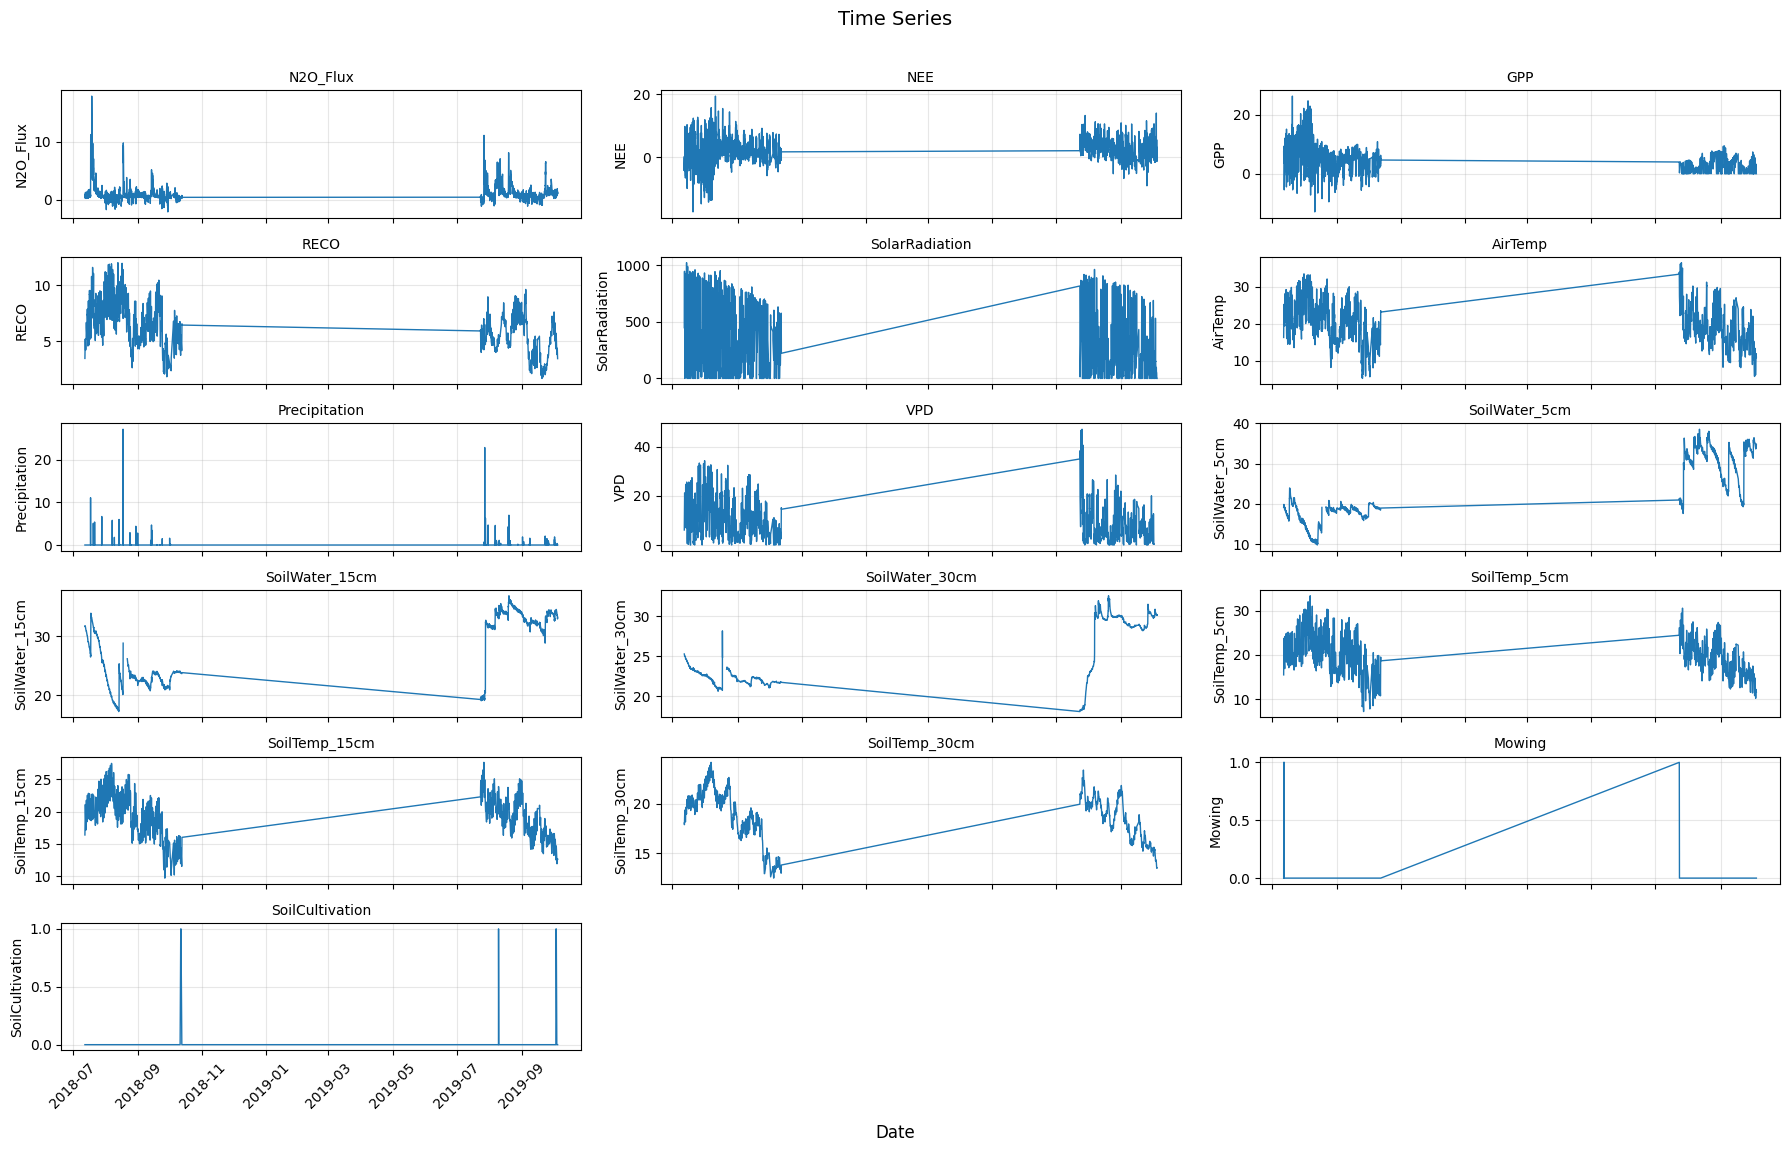

Daily Freq


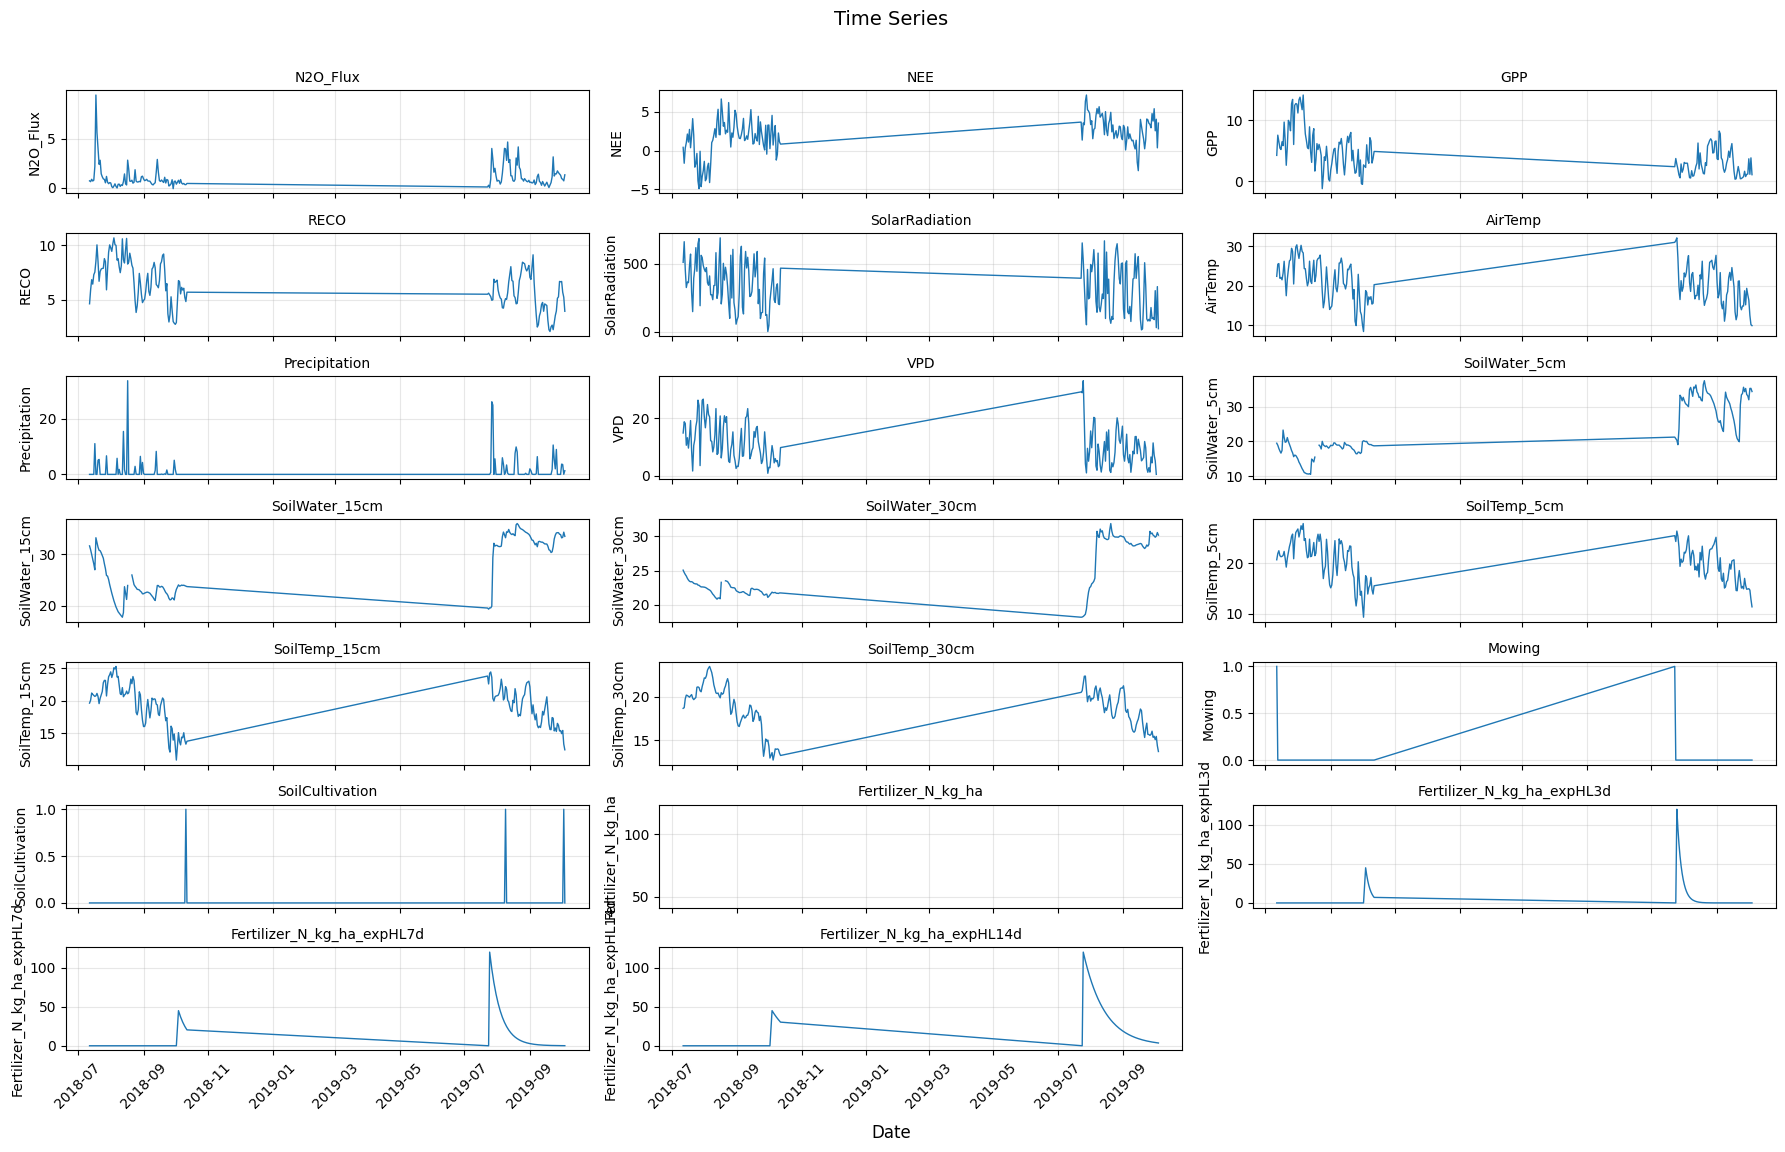

In [22]:
# Variables to plot for half-hourly data (still has the original flags)
vars_to_plot = [
    "N2O_Flux", "NEE", "GPP", "RECO",
    "SolarRadiation", "AirTemp", "Precipitation",
    "VPD", "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm",
    "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "Mowing", "SoilCultivation"  # Removed FertilizerOrganic and FertilizerMineral
]

# Variables to plot for daily data (has CSV-based fertilization)
vars_to_plot_w_fert = [
    "N2O_Flux", "NEE", "GPP", "RECO",
    "SolarRadiation", "AirTemp", "Precipitation",
    "VPD", "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm",
    "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "Mowing", "SoilCultivation",  # Removed FertilizerOrganic and FertilizerMineral
    "Fertilizer_N_kg_ha",  # From CSV
    "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d", "Fertilizer_N_kg_ha_expHL14d"
]

# Daily averages
print("Raw Data")
plot_time_series(oensingen_1, vars_to_plot)
print("Daily Freq")
plot_time_series(oensingen_1_daily, vars_to_plot_w_fert)

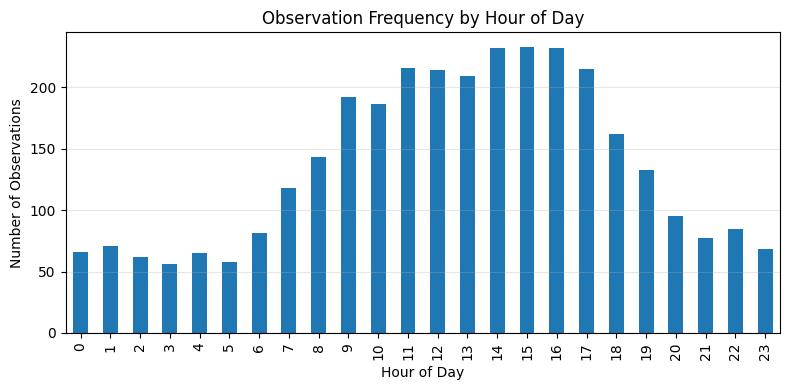

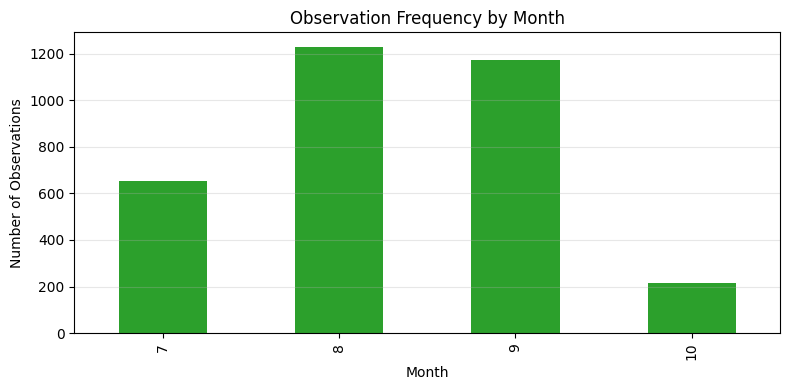

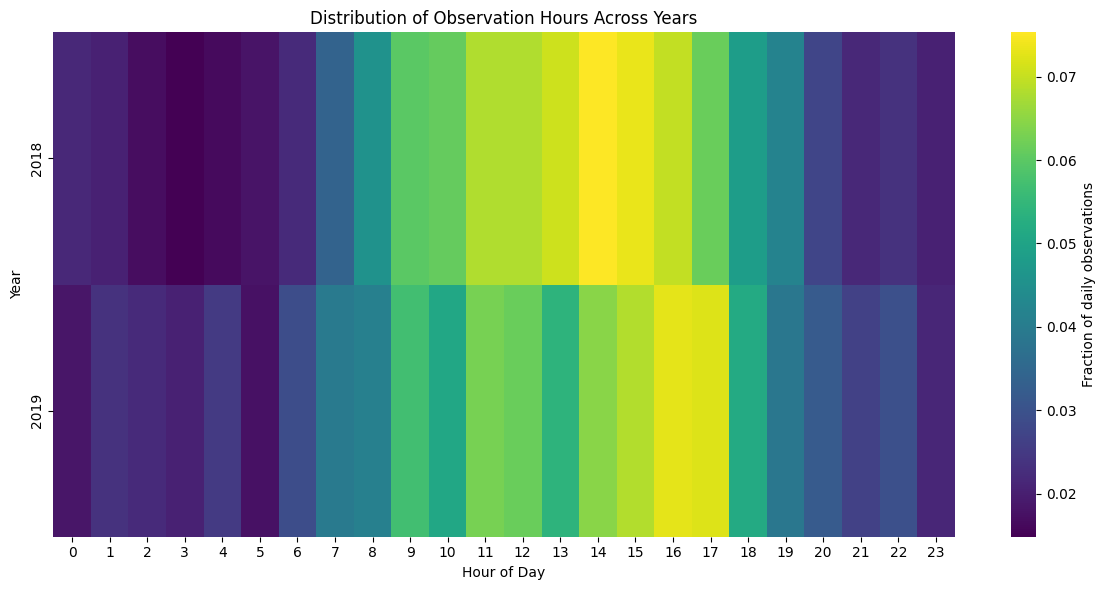

In [23]:
# count observations per hour
hourly_counts = oensingen_1["hour"].value_counts().sort_index()

# plot
plt.figure(figsize=(8,4))
hourly_counts.plot(kind="bar")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Observations")
plt.title("Observation Frequency by Hour of Day")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# count per month
monthly_counts = oensingen_1["month"].value_counts().sort_index()

# plot
plt.figure(figsize=(8,4))
monthly_counts.plot(kind="bar", color="tab:green")
plt.xlabel("Month")
plt.ylabel("Number of Observations")
plt.title("Observation Frequency by Month")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# group by year × hour
hour_year_counts = (
    oensingen_1.groupby(["year", "hour"])
    .size()
    .unstack(fill_value=0)
)

# normalize by total per year (to compare proportions)
hour_year_norm = hour_year_counts.div(hour_year_counts.sum(axis=1), axis=0)

# plot as heatmap
plt.figure(figsize=(12,6))
sns.heatmap(hour_year_norm, cmap="viridis", cbar_kws={"label": "Fraction of daily observations"})
plt.xlabel("Hour of Day")
plt.ylabel("Year")
plt.title("Distribution of Observation Hours Across Years")
plt.tight_layout()
plt.show()

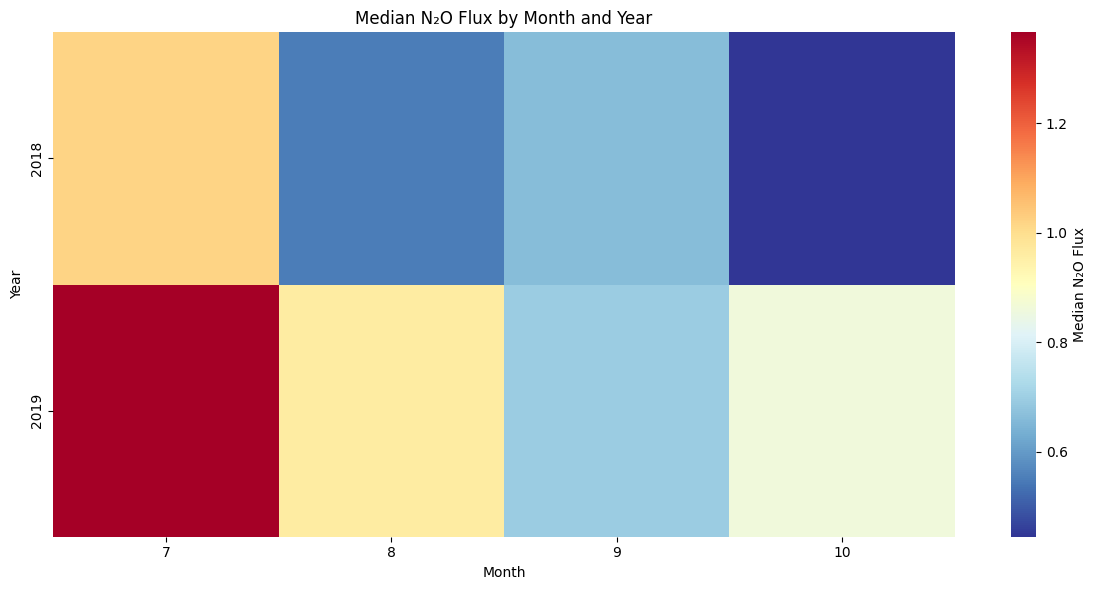

/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_98447/3820657098.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  oensingen_1.groupby(["T5_bin", "T15_bin"])["N2O_Flux"]


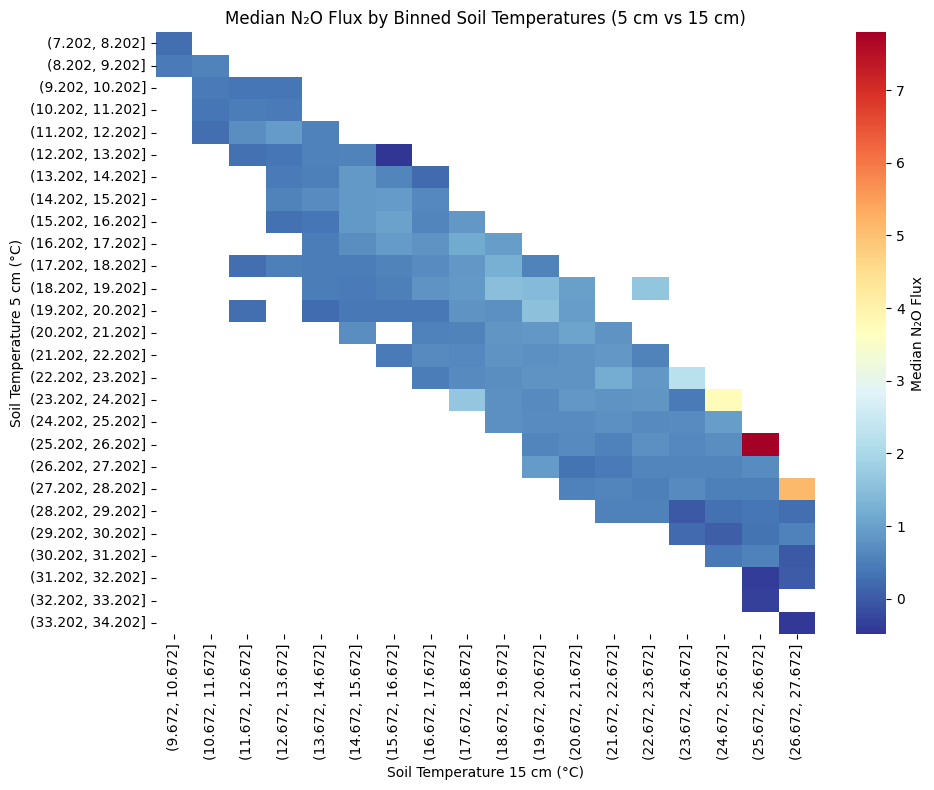

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# compute median N₂O flux per year × hour
median_flux = (
    oensingen_1.groupby(["year", "month"])["N2O_Flux"]
    .median()
    .unstack(fill_value=np.nan)
)

# plot heatmap
plt.figure(figsize=(12,6))
sns.heatmap(
    median_flux,
    cmap="RdYlBu_r",
    cbar_kws={"label": "Median N₂O Flux"},
)
plt.xlabel("Month")
plt.ylabel("Year")
plt.title("Median N₂O Flux by Month and Year")
plt.tight_layout()
plt.show()

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# define bin edges for both temperatures
bins_5cm = np.arange(oensingen_1["SoilTemp_5cm"].min(), oensingen_1["SoilTemp_5cm"].max()+1, 1)
bins_15cm = np.arange(oensingen_1["SoilTemp_15cm"].min(), oensingen_1["SoilTemp_15cm"].max()+1, 1)

# create binned categories
oensingen_1["T5_bin"] = pd.cut(oensingen_1["SoilTemp_5cm"], bins=bins_5cm)
oensingen_1["T15_bin"] = pd.cut(oensingen_1["SoilTemp_15cm"], bins=bins_15cm)

# compute median flux per 2D bin
median_flux_binned = (
    oensingen_1.groupby(["T5_bin", "T15_bin"])["N2O_Flux"]
    .median()
    .unstack(fill_value=np.nan)
)

# plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    median_flux_binned,
    cmap="RdYlBu_r",
    cbar_kws={"label": "Median N₂O Flux"},
)
plt.xlabel("Soil Temperature 15 cm (°C)")
plt.ylabel("Soil Temperature 5 cm (°C)")
plt.title("Median N₂O Flux by Binned Soil Temperatures (5 cm vs 15 cm)")
plt.tight_layout()
plt.show()

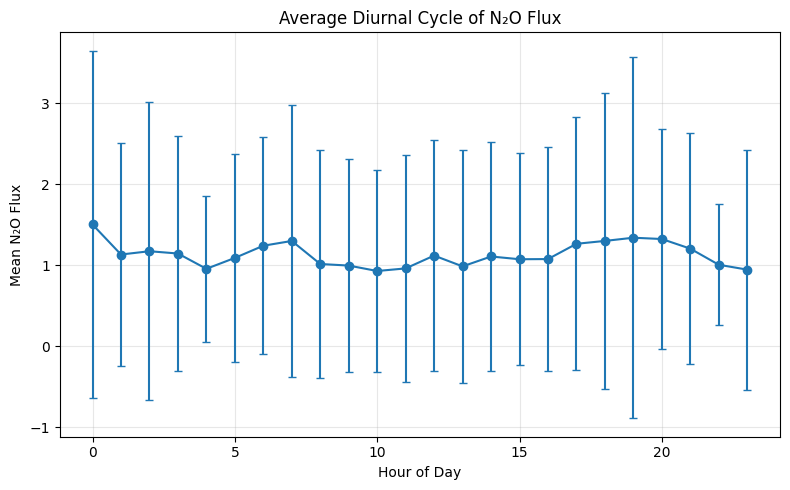

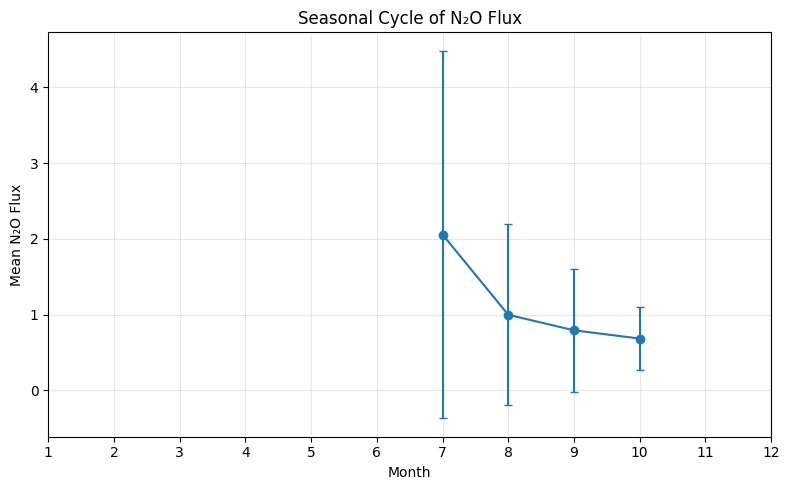

In [25]:
hourly_mean = oensingen_1.groupby("hour")["N2O_Flux"].mean()
hourly_std  = oensingen_1.groupby("hour")["N2O_Flux"].std()

plt.figure(figsize=(8, 5))
plt.errorbar(hourly_mean.index, hourly_mean, yerr=hourly_std, fmt="-o", capsize=3)
plt.xlabel("Hour of Day")
plt.ylabel("Mean N₂O Flux")
plt.title("Average Diurnal Cycle of N₂O Flux")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

monthly_mean = oensingen_1.groupby("month")["N2O_Flux"].mean()
monthly_std  = oensingen_1.groupby("month")["N2O_Flux"].std()

plt.figure(figsize=(8, 5))
plt.errorbar(monthly_mean.index, monthly_mean, yerr=monthly_std, fmt="-o", capsize=3)
plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Mean N₂O Flux")
plt.title("Seasonal Cycle of N₂O Flux")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

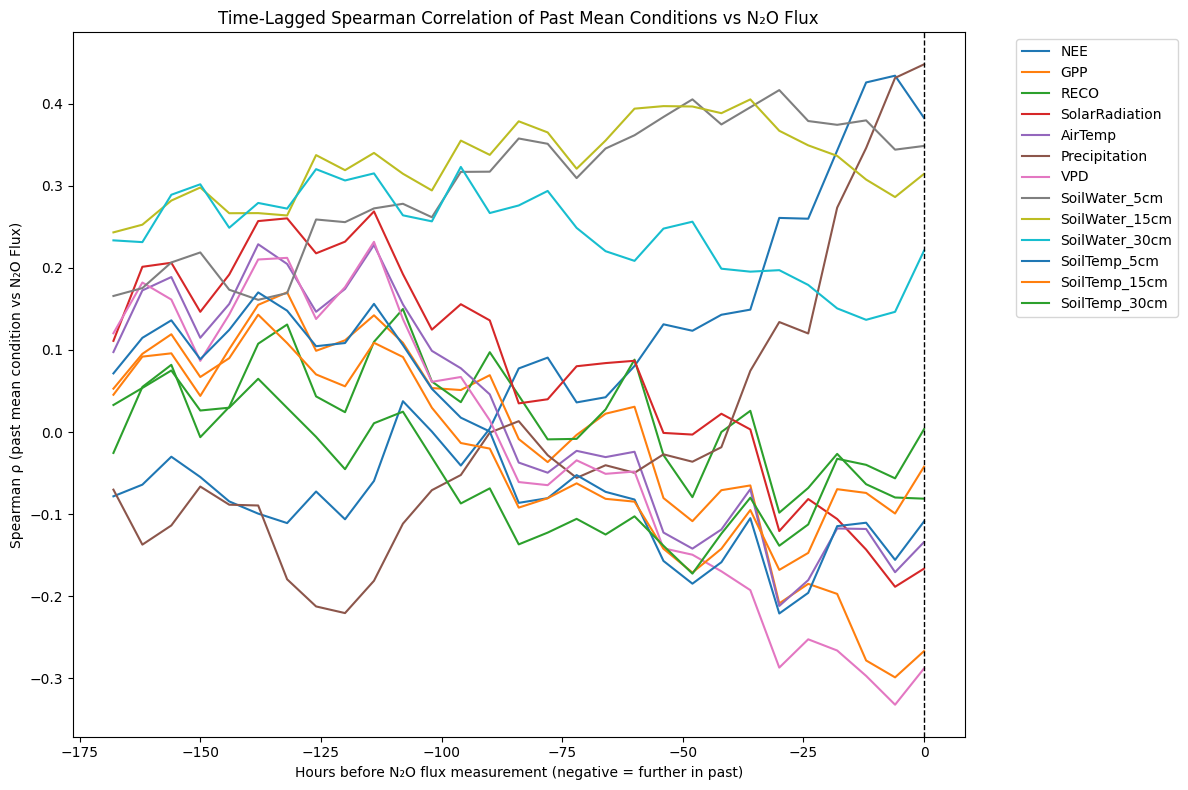

In [26]:
from scipy.stats import spearmanr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Base setup ---
oensingen_1_time_index = oensingen_1.copy()

predictors = [
    "NEE", "GPP", "RECO",
    "SolarRadiation", "AirTemp", "Precipitation", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm",
    "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
]

target = "N2O_Flux"

# --- Parameters ---
window_hours = 24        # window size for averaging (past 24h)
step_hours   = 6        # step between lags
max_hours    = 7 * 24    # look back 1 week (you can extend to 5 weeks)
offsets      = range(0, -max_hours - step_hours, -step_hours)  # only past (0, -24, -48, ...)

# --- Rolling mean of predictors (24h backward window) ---
window = f"{window_hours}h"
rolling_means = oensingen_1_time_index[predictors].rolling(window=window, closed="left").mean()

# --- Compute lag correlations (Spearman) ---
lag_corrs = {}

for var in predictors:
    corrs = []
    for offset in offsets:
        shifted = rolling_means[var].shift(freq=pd.Timedelta(hours=offset))
        aligned = oensingen_1_time_index[[target]].join(shifted.rename("past_mean")).dropna()
        if len(aligned) > 2:
            rho, _ = spearmanr(aligned[target], aligned["past_mean"])
            corrs.append(rho)
        else:
            corrs.append(np.nan)
    lag_corrs[var] = (list(offsets), corrs)

# --- Plot results ---
plt.figure(figsize=(12, 8))
for var, (offsets, corrs) in lag_corrs.items():
    plt.plot(offsets, corrs, label=var)

plt.axvline(0, color="k", linestyle="--", lw=1)
plt.xlabel("Hours before N₂O flux measurement (negative = further in past)")
plt.ylabel("Spearman ρ (past mean condition vs N₂O Flux)")
plt.title("Time-Lagged Spearman Correlation of Past Mean Conditions vs N₂O Flux")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

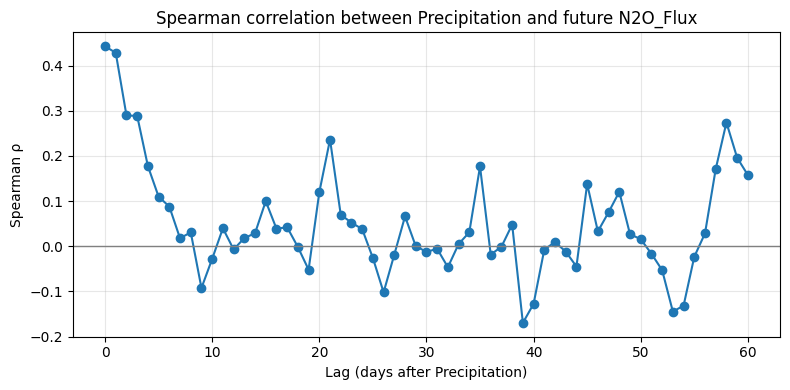

Peak Spearman correlation at lag = 0 days (ρ = 0.443)


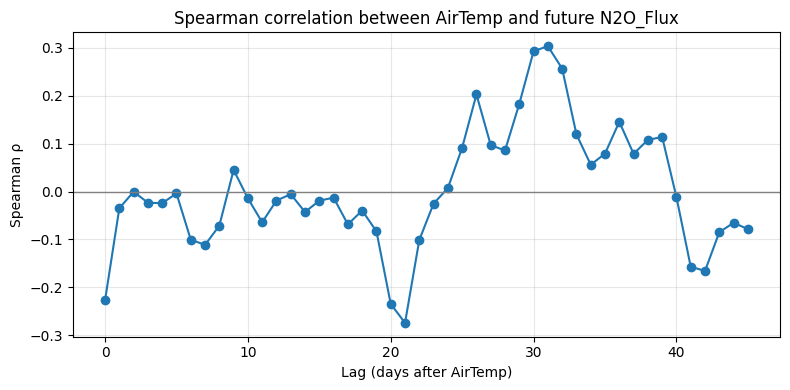

Peak Spearman correlation at lag = 31 days (ρ = 0.304)


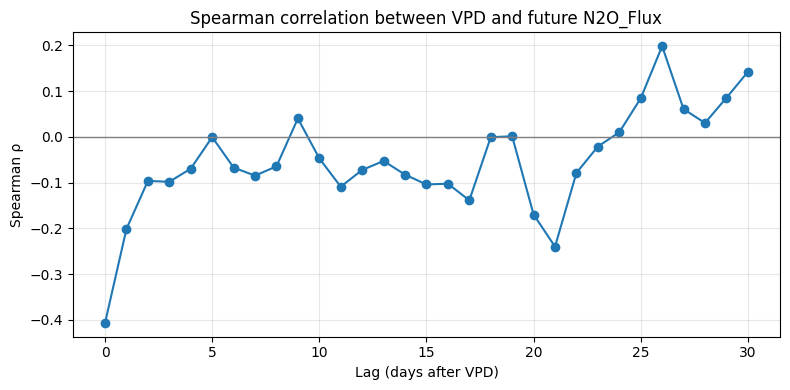

Peak Spearman correlation at lag = 26 days (ρ = 0.198)


In [27]:
from scipy.stats import spearmanr

def plot_lag_correlation(df, col, target="N2O_Flux", max_lag=60, resample_daily=True):
    """
    Compute and plot the Spearman correlation between a predictor and target variable
    over increasing day lags (calendar-based).

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with a DatetimeIndex.
    col : str
        Column name of the predictor variable (e.g. "Precipitation").
    target : str, optional
        Column name of the target variable, by default "N2O_Flux".
    max_lag : int, optional
        Maximum lag in days, by default 60.
    resample_daily : bool, optional
        If True, resample to daily mean (useful if data is sub-daily).

    Returns
    -------
    pd.DataFrame
        DataFrame with 'lag' and 'spearman_r' for each lag.
    """

    # --- Ensure datetime index ---
    df = df.copy()
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    # --- Optional daily resampling ---
    if resample_daily:
        df = df.select_dtypes(include=[np.number]).resample("D").mean()

    # --- Filter for valid positive flux values ---
    df = df[df[target] >= 0][[col, target]].dropna(subset=[target])

    # --- Compute lag correlations ---
    lags = np.arange(0, max_lag + 1)
    corrs = []

    for lag in lags:
        shifted = df[col].shift(freq=pd.to_timedelta(lag, unit="D"))
        aligned = pd.concat([df[target], shifted], axis=1, join="inner").dropna()

        if aligned.empty:
            corrs.append(np.nan)
        else:
            r, _ = spearmanr(aligned[target], aligned[col])
            corrs.append(r)

    # --- Store results ---
    result = pd.DataFrame({"lag_days": lags, "spearman_r": corrs})

    # --- Plot ---
    plt.figure(figsize=(8, 4))
    plt.plot(result["lag_days"], result["spearman_r"], marker="o", color="tab:blue")
    plt.axhline(0, color="gray", lw=1)
    plt.xlabel(f"Lag (days after {col})")
    plt.ylabel("Spearman ρ")
    plt.title(f"Spearman correlation between {col} and future {target}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Report peak correlation ---
    best_lag = result["lag_days"].iloc[np.nanargmax(result["spearman_r"])]
    best_r = np.nanmax(result["spearman_r"])
    print(f"Peak Spearman correlation at lag = {best_lag} days (ρ = {best_r:.3f})")

plot_lag_correlation(oensingen_1, col="Precipitation", max_lag=60)
plot_lag_correlation(oensingen_1, col="AirTemp", max_lag=45)
plot_lag_correlation(oensingen_1, col="VPD", max_lag=30)

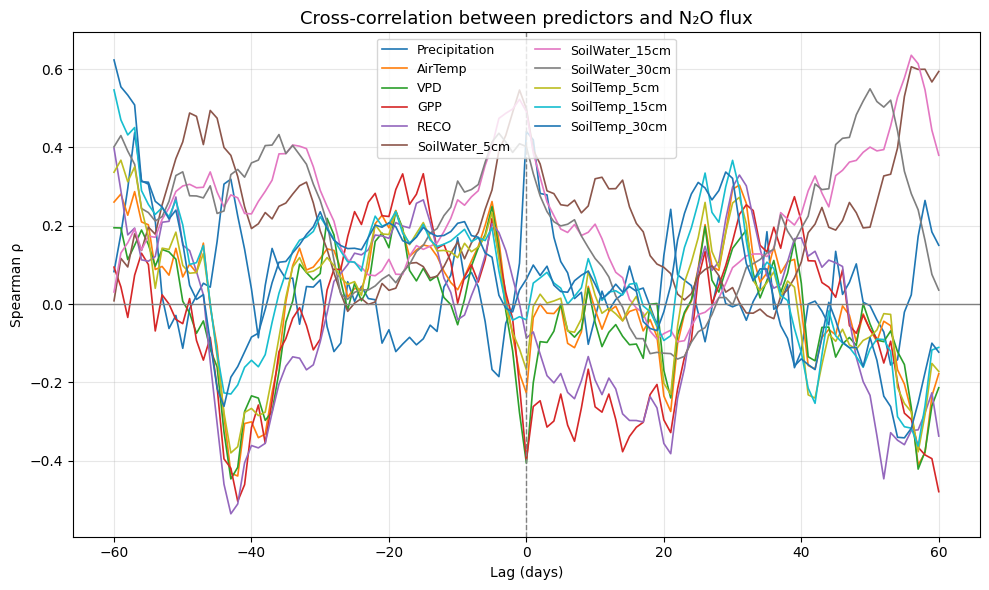

          Variable  Best lag (days)  Max corr (ρ)
6   SoilWater_15cm               56         0.635
10   SoilTemp_30cm              -60         0.623
5    SoilWater_5cm               56         0.606
7   SoilWater_30cm               50         0.550
9    SoilTemp_15cm              -60         0.547
4             RECO              -43        -0.536
3              GPP              -42        -0.504
2              VPD              -43        -0.447
0    Precipitation                0         0.440
1          AirTemp              -42        -0.439
8     SoilTemp_5cm              -43        -0.380


In [28]:
def cross_correlation_single(df, predictor_vars, target="N2O_Flux", max_lag=60):
    df = df.copy()
    if not isinstance(df.index, pd.DatetimeIndex):
        if "Date" in df.columns:
            df["Date"] = pd.to_datetime(df["Date"])
            df = df.set_index("Date")
        else:
            raise ValueError("DataFrame must have a DatetimeIndex or 'Date' column")

    df = df[df[target] >= 0].dropna(subset=[target])
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    predictor_vars = [v for v in predictor_vars if v in numeric_cols]
    lags = np.arange(-max_lag, max_lag + 1)
    
    # Sort by index
    df = df.sort_index()
    corrs_dict = {}

    # Compute correlations for each predictor
    for var in predictor_vars:
        corrs = []
        for lag in lags:
            shifted = df[var].shift(freq=pd.to_timedelta(lag, unit="D"))
            aligned = pd.concat([df[target], shifted], axis=1, join="inner").dropna()
            rho = np.nan if aligned.empty else spearmanr(aligned[target], aligned[var])[0]
            corrs.append(rho)
        corrs_dict[var] = corrs

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for var, corrs in corrs_dict.items():
        ax.plot(lags, corrs, lw=1.2, label=var)

    ax.axhline(0, color="gray", lw=1)
    ax.axvline(0, color="gray", lw=1, ls="--")
    ax.set_xlabel("Lag (days)")
    ax.set_ylabel("Spearman ρ")
    ax.set_title("Cross-correlation between predictors and N₂O flux", fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()

    # --- Summary ---
    summary_rows = []
    for var, corrs in corrs_dict.items():
        best_idx = np.nanargmax(np.abs(corrs))
        summary_rows.append({
            "Variable": var,
            "Best lag (days)": int(lags[best_idx]),
            "Max corr (ρ)": corrs[best_idx],
        })

    summary_df = pd.DataFrame(summary_rows)
    summary_df = (
        summary_df
        .sort_values(
            by="Max corr (ρ)",
            ascending=False,
            key=lambda col: np.abs(col) if col.name == "Max corr (ρ)" else col
        )
        .round(3)
    )

    return summary_df

predictors = [
    "Precipitation", "AirTemp", "VPD", "GPP", "RECO",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm",
    "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm"
]

summary = cross_correlation_single(oensingen_1_daily, predictor_vars=predictors, max_lag=60)
print(summary)

# PCA plots

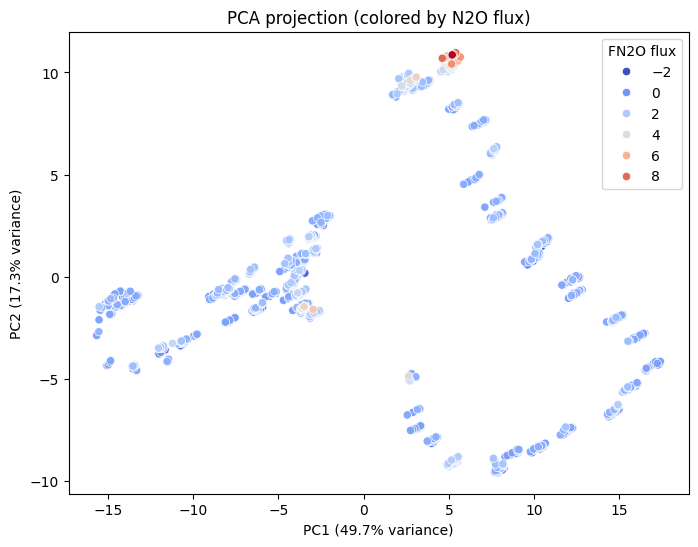

In [41]:
oensingen_1_clean = oensingen_1.dropna()
oensingen_1_clean = oensingen_1_clean.sort_values(
    by="N2O_Flux",
    ascending=True  # ascending puts zeros first, descending puts them last
)

X_1 = oensingen_1_clean.drop(columns=["N2O_Flux", "Date", "T5_bin", "T15_bin"])
y_1 = oensingen_1_clean["N2O_Flux"]

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Standardize predictors
X_scaled_1 = StandardScaler().fit_transform(X_1)

# Run PCA (2 components for visualization)
pca_1 = PCA(n_components=2)
X_pca_1 = pca_1.fit_transform(X_scaled_1)

# Create DataFrame for plotting
pca_df_1 = pd.DataFrame(X_pca_1, columns=['PC1', 'PC2'])
pca_df_1["FN2O"] = y_1.values

# Scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df_1, x="PC1", y="PC2", hue="FN2O", palette="coolwarm")
plt.title("PCA projection (colored by N2O flux)")
plt.xlabel(f"PC1 ({pca_1.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca_1.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(title="FN2O flux", loc="best")
plt.show()

In [42]:
loadings = pd.DataFrame(
    pca_1.components_.T,
    index=X_1.columns,
    columns=["PC1", "PC2"]
)
print(loadings.sort_values("PC1", ascending=False))

                                PC1       PC2
AirTemp_roll7d_sum         0.113289  0.006927
AirTemp_roll7d_mean        0.113289  0.006927
SoilTemp_5cm_roll5d_mean   0.111986  0.002729
SoilTemp_5cm_roll5d_sum    0.111986  0.002729
AirTemp_roll5d_sum         0.111591  0.015250
...                             ...       ...
SoilWater_5cm_lag1d_daily -0.072543  0.139891
NEE_roll7d_sum            -0.077955  0.053294
NEE_roll7d_mean           -0.077955  0.053294
SoilWater_5cm             -0.082598  0.117429
month                     -0.085870 -0.099004

[155 rows x 2 columns]


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


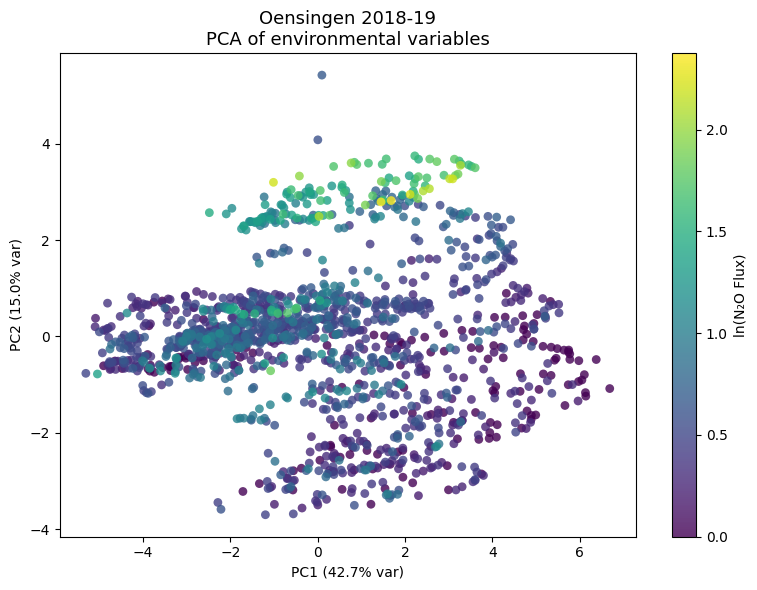

In [43]:
import matplotlib.cm as cm

# --- transformation ---
oensingen_1_clean["N2O_Flux_ln"] = np.where(
    oensingen_1_clean["N2O_Flux"] > 0,
    np.log1p(oensingen_1_clean["N2O_Flux"]),
    0
)

# =============================================
# 1️⃣ Define variables and plotting function
# =============================================
base_vars = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm",
    "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO", "Mowing", "FertilizerMineral", "SoilCultivation"
]

def plot_pca(df, title):
    # Drop rows with missing values in required columns
    df_clean = df.dropna(subset=base_vars + ["N2O_Flux_ln"]).copy()
    
    # Standardize variables
    X_scaled = StandardScaler().fit_transform(df_clean[base_vars])
    
    # Run PCA
    pca = PCA(n_components=2)
    pcs = pca.fit_transform(X_scaled)
    df_clean["PC1"] = pcs[:, 0]
    df_clean["PC2"] = pcs[:, 1]

    # Sort by N2O_Flux (so larger appear on top)
    df_clean = df_clean.sort_values("N2O_Flux_ln", ascending=True)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(
        df_clean["PC1"], df_clean["PC2"],
        c=df_clean["N2O_Flux_ln"],
        cmap=cm.viridis,
        s=40, alpha=0.8, edgecolor="none"
    )

    # Labels and aesthetics
    ax.set_title(f"{title}\nPCA of environmental variables", fontsize=13)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("ln(N₂O Flux)")
    plt.tight_layout()
    plt.show()

# =============================================
# 2️⃣ Run for oensingen 2018-19
# =============================================
plot_pca(oensingen_1_clean, "Oensingen 2018-19")

# UMAP plots

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


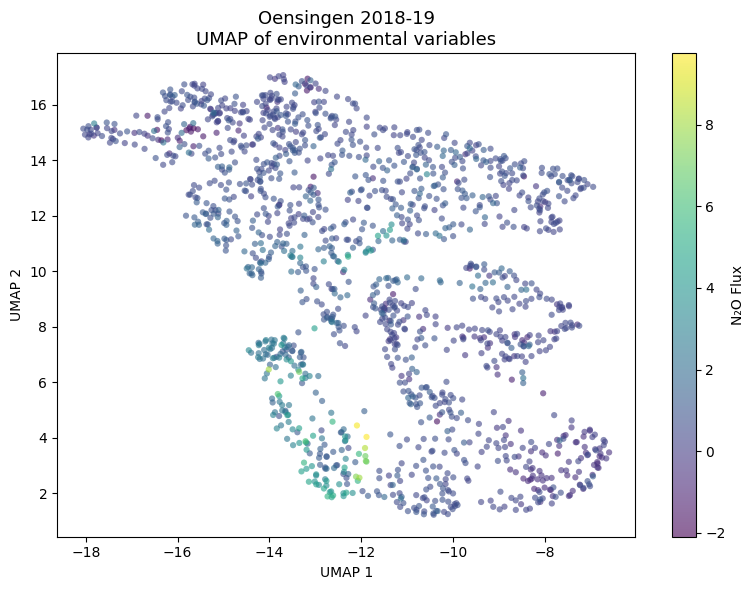

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import umap
import matplotlib.cm as cm

# =============================================
# 1️⃣ Define variables and plotting function
# =============================================
base_vars = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm",
    "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO", "Mowing", "FertilizerMineral", "SoilCultivation"
]


def plot_umap(df, title, n_neighbors=50, min_dist=0.5, random_state=42):
    # Drop rows with missing values
    df_clean = df.dropna(subset=base_vars + ["N2O_Flux"]).copy()

    # Standardize
    X_scaled = StandardScaler().fit_transform(df_clean[base_vars])

    # Run UMAP
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="euclidean",
        random_state=random_state
    )
    embedding = reducer.fit_transform(X_scaled)
    df_clean["UMAP1"] = embedding[:, 0]
    df_clean["UMAP2"] = embedding[:, 1]

    # Sort by N2O_Flux so high values are plotted last (on top)
    df_clean = df_clean.sort_values("N2O_Flux", ascending=True)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(
        df_clean["UMAP1"], df_clean["UMAP2"],
        c=df_clean["N2O_Flux"],
        cmap=cm.viridis,
        s=20, alpha=0.6, edgecolor="none"
    )

    ax.set_title(f"{title}\nUMAP of environmental variables", fontsize=13)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("N₂O Flux")
    plt.tight_layout()
    plt.show()

# =============================================
# 2️⃣ Run for Oensingen 2018-19
# =============================================
plot_umap(oensingen_1_clean, "Oensingen 2018-19")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


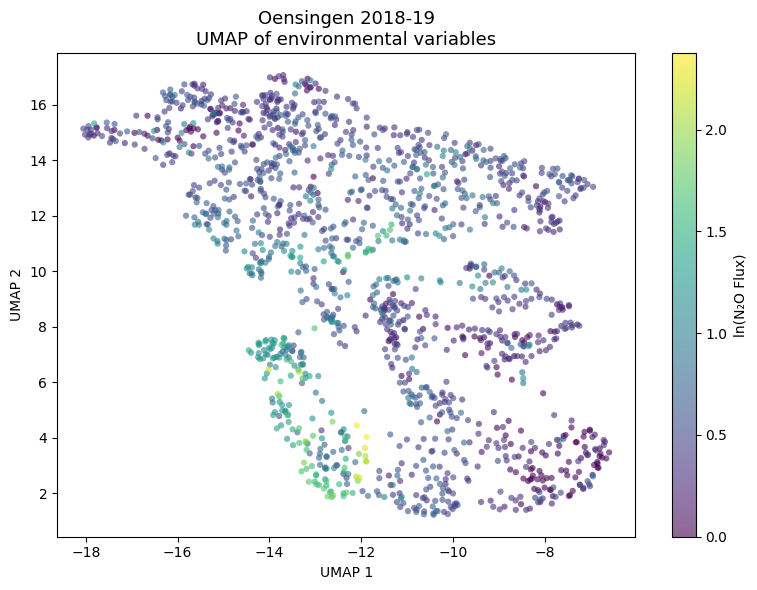

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import umap
import matplotlib.cm as cm

# =============================================
# 1️⃣ Define variables and plotting function
# =============================================
base_vars = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm",
    "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO", "Mowing", "FertilizerMineral", "SoilCultivation"
]


def plot_umap(df, title, n_neighbors=50, min_dist=0.5, random_state=42):
    # Drop rows with missing values
    df_clean = df.dropna(subset=base_vars + ["N2O_Flux_ln"]).copy()

    # Standardize
    X_scaled = StandardScaler().fit_transform(df_clean[base_vars])

    # Run UMAP
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="euclidean",
        random_state=random_state
    )
    embedding = reducer.fit_transform(X_scaled)
    df_clean["UMAP1"] = embedding[:, 0]
    df_clean["UMAP2"] = embedding[:, 1]

    # Sort by N2O_Flux so high values are plotted last (on top)
    df_clean = df_clean.sort_values("N2O_Flux_ln", ascending=True)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(
        df_clean["UMAP1"], df_clean["UMAP2"],
        c=df_clean["N2O_Flux_ln"],
        cmap=cm.viridis,
        s=20, alpha=0.6, edgecolor="none"
    )

    ax.set_title(f"{title}\nUMAP of environmental variables", fontsize=13)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("ln(N₂O Flux)")
    plt.tight_layout()
    plt.show()

# =============================================
# 2️⃣ Run for Oensingen 2018-19
# =============================================
plot_umap(oensingen_1_clean, "Oensingen 2018-19")

# t-SNE plots

In [46]:
from sklearn.preprocessing import StandardScaler

# Drop or fill NaNs
X_1 = X_1.dropna()
y_1 = y_1.loc[X_1.index]

# Scale predictors
X_scaled_1 = StandardScaler().fit_transform(X_1)

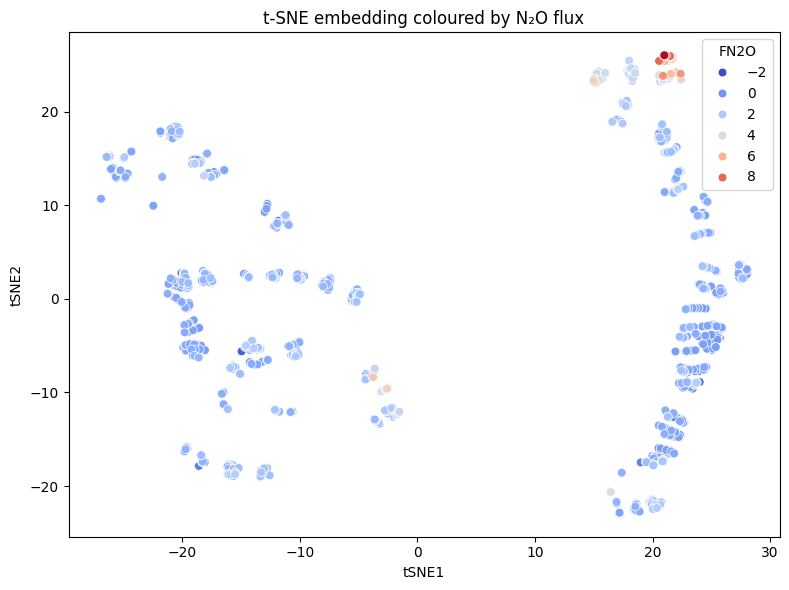

In [47]:
from sklearn.manifold import TSNE

tsne_1 = TSNE(n_components=2, perplexity=90, random_state=42)
X_tsne_1 = tsne_1.fit_transform(X_scaled_1)

tsne_df_1 = pd.DataFrame(X_tsne_1, columns=["tSNE1", "tSNE2"])
tsne_df_1["FN2O"] = y_1.values

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=tsne_df_1, x="tSNE1", y="tSNE2",
    hue="FN2O", palette="coolwarm", s=40
)
plt.title("t-SNE embedding coloured by N₂O flux")
plt.tight_layout()
plt.show()

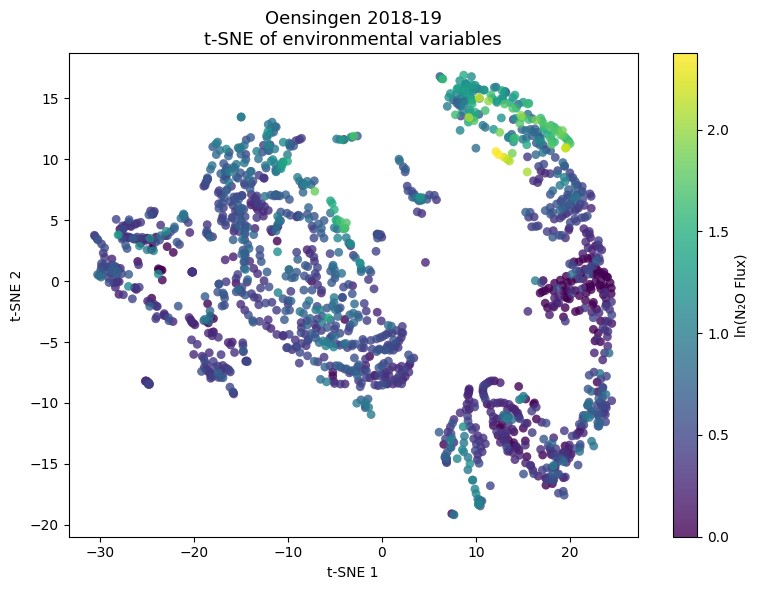

In [48]:
# =============================================
# 1️⃣ Define variables and plotting function
# =============================================
base_vars = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm",
    "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO", "Mowing", "FertilizerMineral", "SoilCultivation"
]

def plot_tsne(df, title, perplexity=100, learning_rate=200, random_state=42):
    # Drop missing values
    df_clean = df.dropna(subset=base_vars + ["N2O_Flux_ln"]).copy()

    # Standardize features
    X_scaled = StandardScaler().fit_transform(df_clean[base_vars])

    # Run t-SNE
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate=learning_rate,
        init="pca",
        random_state=random_state
    )
    tsne_results = tsne.fit_transform(X_scaled)

    df_clean["tSNE1"] = tsne_results[:, 0]
    df_clean["tSNE2"] = tsne_results[:, 1]

    # Sort by N2O_Flux for plotting order
    df_clean = df_clean.sort_values("N2O_Flux_ln", ascending=True)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(
        df_clean["tSNE1"], df_clean["tSNE2"],
        c=df_clean["N2O_Flux_ln"],
        cmap=cm.viridis,
        s=40, alpha=0.8, edgecolor="none"
    )

    ax.set_title(f"{title}\nt-SNE of environmental variables", fontsize=13)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("ln(N₂O Flux)")
    plt.tight_layout()
    plt.show()

# =============================================
# 2️⃣ Run for Oensingen 2018-19
# =============================================
plot_tsne(oensingen_1_clean, "Oensingen 2018-19")